# Preprocessing & Pembuatan Model ML — Diabetes Predictor

**Alur notebook ini:**
1. Load dataset bersih hasil EDA
2. Preprocessing (scaling, train-test split)
3. Latih & bandingkan 3 model ML
4. Evaluasi model terbaik secara mendalam
5. Simpan model ke file `.pkl` untuk dipakai di app Streamlit

---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Evaluasi
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
PALETTE = ['#378ADD', '#E24B4A']

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


## 2. Load Dataset

In [2]:
# Gunakan dataset bersih hasil EDA
# Kalau belum punya diabetes_clean.csv, jalankan dulu eda_diabetes.ipynb
try:
    df = pd.read_csv('../data/diabetes_clean.csv')
    print('✅ Loaded: diabetes_clean.csv (sudah dibersihkan dari EDA)')
except FileNotFoundError:
    df = pd.read_csv('../data/diabetes.csv')
    # Imputasi cepat kalau belum ada file bersih
    cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    for col in cols:
        for outcome in [0, 1]:
            med = df.loc[(df['Outcome'] == outcome) & (df[col] != 0), col].median()
            df.loc[(df[col] == 0) & (df['Outcome'] == outcome), col] = med
    print('⚠️  Loaded: diabetes.csv (imputasi darurat diterapkan)')

print(f'Shape: {df.shape}')
df.head()

✅ Loaded: diabetes_clean.csv (sudah dibersihkan dari EDA)
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


## 3. Preprocessing

In [3]:
# Pisahkan fitur (X) dan label (y)
FEATURES = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df[FEATURES]
y = df['Outcome']

print(f'Shape X : {X.shape}')
print(f'Shape y : {y.shape}')
print(f'Distribusi y:\n{y.value_counts()}')

Shape X : (768, 8)
Shape y : (768,)
Distribusi y:
Outcome
0    500
1    268
Name: count, dtype: int64


In [4]:
# Train-test split — stratified agar distribusi kelas tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # penting untuk dataset imbalanced
)

print(f'Train set : {X_train.shape[0]} baris')
print(f'Test set  : {X_test.shape[0]} baris')
print()
print('Distribusi kelas di train set:')
print(y_train.value_counts())
print()
print('Distribusi kelas di test set:')
print(y_test.value_counts())

Train set : 614 baris
Test set  : 154 baris

Distribusi kelas di train set:
Outcome
0    400
1    214
Name: count, dtype: int64

Distribusi kelas di test set:
Outcome
0    100
1     54
Name: count, dtype: int64


In [5]:
# Feature Scaling — StandardScaler
# PENTING: fit hanya pada training data, transform pada keduanya
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Verifikasi: rata-rata training data harus mendekati 0, std mendekati 1
print('Verifikasi scaling pada training data:')
print(f'  Mean : {X_train_scaled.mean(axis=0).round(4)}')
print(f'  Std  : {X_train_scaled.std(axis=0).round(4)}')
print('\n✅ Scaling berhasil!')

Verifikasi scaling pada training data:
  Mean : [-0. -0.  0. -0.  0. -0. -0. -0.]
  Std  : [1. 1. 1. 1. 1. 1. 1. 1.]

✅ Scaling berhasil!


## 4. Training & Perbandingan Model

In [6]:
# Definisikan semua model yang akan dibandingkan
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_split=5,
        random_state=42, class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        random_state=42
    ),
    'SVM': SVC(
        kernel='rbf', probability=True, random_state=42, class_weight='balanced'
    )
}

# Latih semua model + cross-validation
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print('Melatih model... (mungkin butuh 30-60 detik)\n')
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred   = model.predict(X_test_scaled)
    y_proba  = model.predict_proba(X_test_scaled)[:, 1]
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                cv=cv, scoring='f1')
    results.append({
        'Model'          : name,
        'Accuracy'       : accuracy_score(y_test, y_pred),
        'F1-Score'       : f1_score(y_test, y_pred),
        'Precision'      : precision_score(y_test, y_pred),
        'Recall'         : recall_score(y_test, y_pred),
        'ROC-AUC'        : roc_auc_score(y_test, y_proba),
        'CV F1 (mean)'   : cv_scores.mean(),
        'CV F1 (std)'    : cv_scores.std(),
    })
    print(f'✅ {name} selesai')

results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(4))

Melatih model... (mungkin butuh 30-60 detik)

✅ Logistic Regression selesai
✅ Random Forest selesai
✅ Gradient Boosting selesai
✅ SVM selesai


,Accuracy,F1-Score,Precision,Recall,ROC-AUC,CV F1 (mean),CV F1 (std)
Model,,,,,,,
Logistic Regression,0.7468,0.6829,0.6087,0.7778,0.8272,0.7418,0.0315
Random Forest,0.8571,0.7925,0.8077,0.7778,0.9444,0.8312,0.0318
Gradient Boosting,0.8831,0.8302,0.8462,0.8148,0.9552,0.8051,0.0300
SVM,0.8442,0.8000,0.7273,0.8889,0.8981,0.7830,0.0240


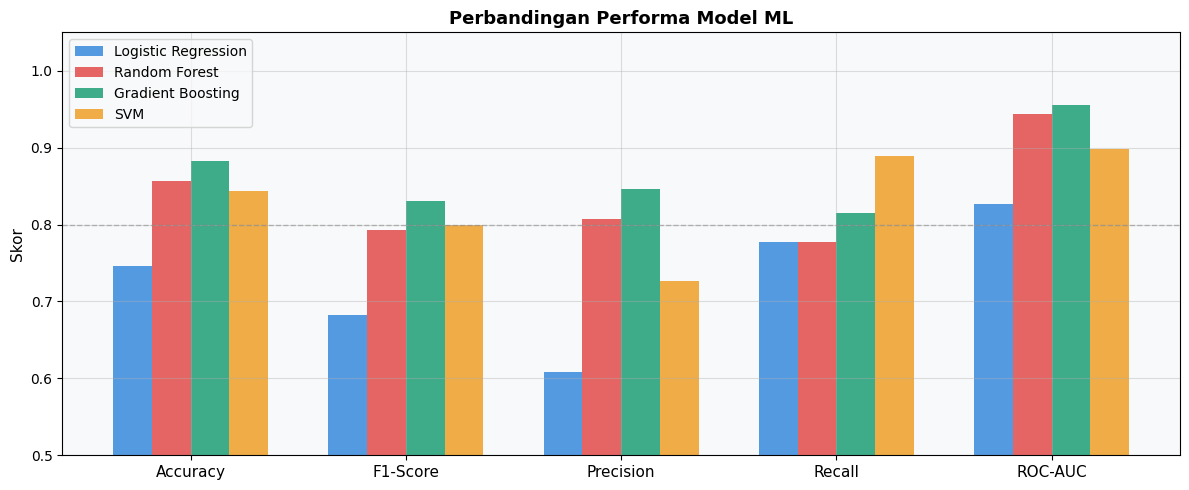

In [7]:
# --- Visualisasi perbandingan model ---
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(metrics))
width   = 0.18
colors  = ['#378ADD', '#E24B4A', '#1D9E75', '#EF9F27']

for i, (name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width, [row[m] for m in metrics],
                  width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Skor', fontsize=11)
ax.set_title('Perbandingan Performa Model ML', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# --- Pilih model terbaik berdasarkan ROC-AUC ---
best_model_name = results_df['ROC-AUC'].idxmax()
best_model      = models[best_model_name]

print(f'🏆 Model terpilih : {best_model_name}')
print(f'   ROC-AUC       : {results_df.loc[best_model_name, "ROC-AUC"]:.4f}')
print(f'   F1-Score      : {results_df.loc[best_model_name, "F1-Score"]:.4f}')
print(f'   Accuracy      : {results_df.loc[best_model_name, "Accuracy"]:.4f}')

🏆 Model terpilih : Gradient Boosting
   ROC-AUC       : 0.9552
   F1-Score      : 0.8302
   Accuracy      : 0.8831


## 5. Evaluasi Model Terbaik Secara Mendalam

In [9]:
y_pred  = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(f'=== Classification Report: {best_model_name} ===')
print(classification_report(y_test, y_pred,
                             target_names=['Tidak Diabetes', 'Diabetes']))

=== Classification Report: Gradient Boosting ===
                precision    recall  f1-score   support

Tidak Diabetes       0.90      0.92      0.91       100
      Diabetes       0.85      0.81      0.83        54

      accuracy                           0.88       154
     macro avg       0.87      0.87      0.87       154
  weighted avg       0.88      0.88      0.88       154



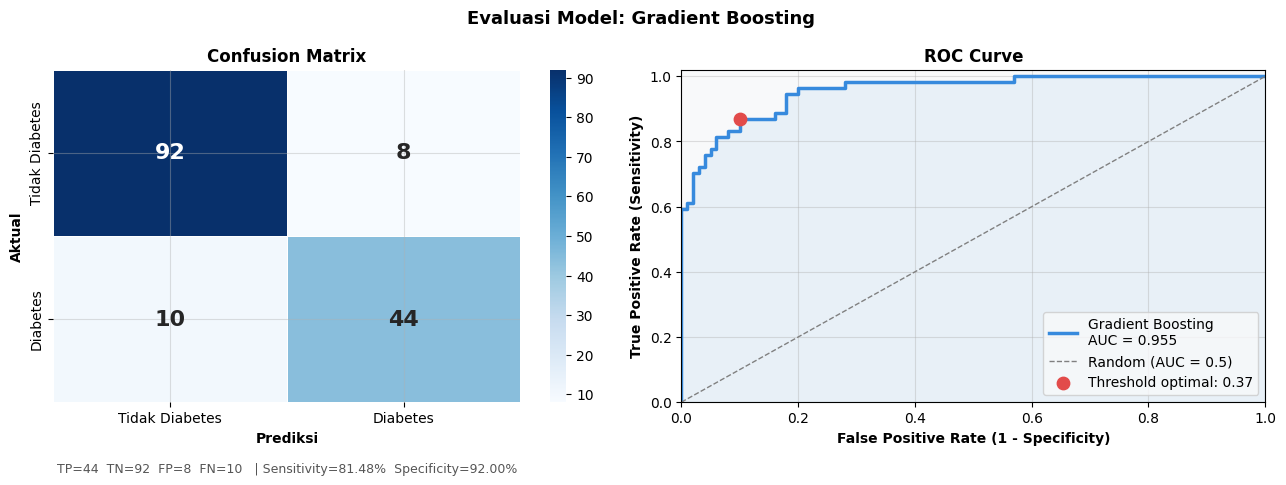


📌 Threshold optimal (Youden): 0.368
   Gunakan threshold ini di app untuk hasil yang lebih seimbang.


In [10]:
# --- Confusion Matrix + ROC Curve (berdampingan) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Evaluasi Model: {best_model_name}', fontsize=13, fontweight='bold')

# -- Confusion Matrix --
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Diabetes', 'Diabetes'],
            yticklabels=['Tidak Diabetes', 'Diabetes'],
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_xlabel('Prediksi', fontweight='bold')
ax.set_ylabel('Aktual', fontweight='bold')

tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.18,
        f'TP={tp}  TN={tn}  FP={fp}  FN={fn}   '
        f'| Sensitivity={tp/(tp+fn):.2%}  Specificity={tn/(tn+fp):.2%}',
        ha='center', va='top', transform=ax.transAxes,
        fontsize=9, color='#555')

# -- ROC Curve --
ax2 = axes[1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

ax2.plot(fpr, tpr, color='#378ADD', linewidth=2.5,
         label=f'{best_model_name}\nAUC = {auc_score:.3f}')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random (AUC = 0.5)')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#378ADD')

# Titik optimal (Youden's J)
j_scores    = tpr - fpr
optimal_idx = np.argmax(j_scores)
opt_fpr, opt_tpr = fpr[optimal_idx], tpr[optimal_idx]
opt_thresh  = thresholds[optimal_idx]
ax2.scatter(opt_fpr, opt_tpr, color='#E24B4A', s=80, zorder=5,
            label=f'Threshold optimal: {opt_thresh:.2f}')

ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
ax2.set_ylabel('True Positive Rate (Sensitivity)', fontweight='bold')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('plot_evaluasi_model.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n📌 Threshold optimal (Youden): {opt_thresh:.3f}')
print('   Gunakan threshold ini di app untuk hasil yang lebih seimbang.')

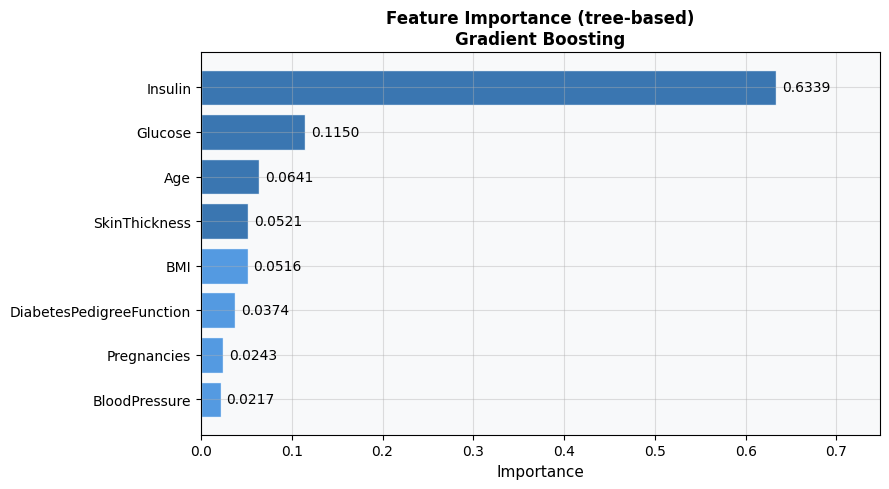

In [11]:
# --- Feature Importance ---
fig, ax = plt.subplots(figsize=(9, 5))

if hasattr(best_model, 'feature_importances_'):
    # Random Forest / Gradient Boosting
    importances = best_model.feature_importances_
    method_name = 'Feature Importance (tree-based)'
elif hasattr(best_model, 'coef_'):
    # Logistic Regression / SVM
    importances = np.abs(best_model.coef_[0])
    method_name = '|Koefisien| (Logistic Regression)'
else:
    importances = np.ones(len(FEATURES))
    method_name = 'N/A'

fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

colors_bar = ['#378ADD' if v < fi_df['Importance'].median() else '#185FA5'
               for v in fi_df['Importance']]
bars = ax.barh(fi_df['Feature'], fi_df['Importance'],
               color=colors_bar, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, fi_df['Importance']):
    ax.text(val + fi_df['Importance'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Importance', fontsize=11)
ax.set_title(f'{method_name}\n{best_model_name}',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, fi_df['Importance'].max() * 1.18)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Simpan Model & Scaler

In [12]:
import os
os.makedirs('../model', exist_ok=True)

# Simpan model terbaik
joblib.dump(best_model, '../model/model.pkl')
joblib.dump(scaler,     '../model/scaler.pkl')

# Simpan juga metadata untuk dipakai di app
import json
metadata = {
    'model_name'       : best_model_name,
    'features'         : FEATURES,
    'accuracy'         : float(results_df.loc[best_model_name, 'Accuracy']),
    'f1_score'         : float(results_df.loc[best_model_name, 'F1-Score']),
    'roc_auc'          : float(results_df.loc[best_model_name, 'ROC-AUC']),
    'optimal_threshold': float(opt_thresh),
    'train_size'       : int(len(X_train)),
    'test_size'        : int(len(X_test)),
}
with open('../model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ File tersimpan:')
print('   ../model/model.pkl        — model ML terbaik')
print('   ../model/scaler.pkl       — StandardScaler')
print('   ../model/metadata.json    — info model untuk app')
print()
print('🚀 Siap dipakai di app.py Streamlit!')
print(json.dumps(metadata, indent=2))

✅ File tersimpan:
   ../model/model.pkl        — model ML terbaik
   ../model/scaler.pkl       — StandardScaler
   ../model/metadata.json    — info model untuk app

🚀 Siap dipakai di app.py Streamlit!
{
  "model_name": "Gradient Boosting",
  "features": [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
  ],
  "accuracy": 0.8831168831168831,
  "f1_score": 0.8301886792452831,
  "roc_auc": 0.9551851851851851,
  "optimal_threshold": 0.3680827382216608,
  "train_size": 614,
  "test_size": 154
}
